2.1 理论计算题
第一问.a·b=2*1+（-1）*4+3*（-2）=-8
第二问.矩阵的形状：2*2,第一行 8 5，第二行1 -2
第三问.Frobenius范数=向量元素的平方和开根号=根号14

2.2 编程题

In [ ]:
import numpy as np

# 1. 创建形状为3×4的随机矩阵X，服从标准正态分布
np.random.seed(42) 
X = np.random.randn(3, 4)
print("X = \n", X)

# 2. 创建形状为4×2的全1矩阵Y
Y = np.ones((4, 2))
print("Y = \n", Y)

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)  
print("Z = \n", Z)

# 4. 输出Z的第一行和第二列交叉处的元素，以及Z的第2行所有元素
element = Z[0, 1]
print("Z的第一行第二列元素:", element)

second_row = Z[1, :]  # 或者 Z[1]
print("Z的第二行所有元素:", second_row)

# 5. 计算Z的Frobenius范数
fro_norm = np.linalg.norm(Z, 'fro')
print("Z的Frobenius范数:", fro_norm)

X = 
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
Y = 
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z = 
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
Z的第一行第二列元素: 2.5291682463487657
Z的第二行所有元素: [1.87835721 1.87835721]
Z的Frobenius范数: 4.616873319476863


3.1 理论计算题 
已知：患病率 𝑃(病)=0.1%=0.001，灵敏度P(阳|病)=99%=0.99，假阳性率P(阳|无病)=2%=0.02，求P（病|阳）。
贝叶斯公式：P(病|阳)=P(阳|病)·P(病)/P(阳)
P(阳)=P(阳|病)·P(病)+P(阳|无病)·P(无病)=0.99*0.001+0.02*0.999=0.02097
P(病|阳)=0.00099/0.02097，约等于0.0472，即4.72%

3.2 编程题

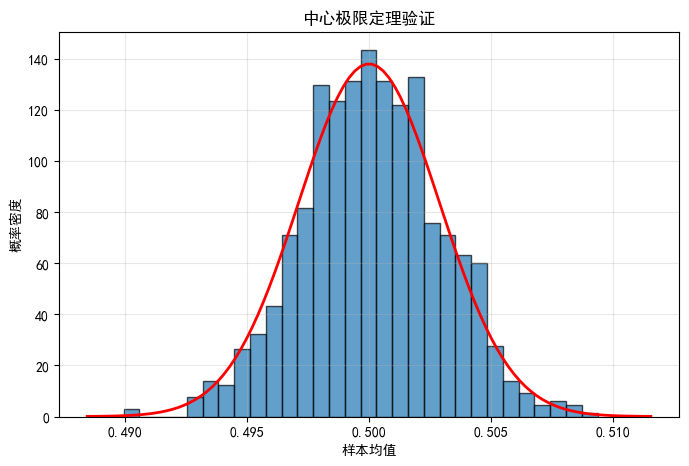

样本均值的实际方差: 0.000008
理论方差 (1/12n): 0.000008


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 设置中文字体（解决小方框问题）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

# 参数设置
n = 10000   # 每次抽样的样本量
m = 1000    # 重复次数

# 1.生成m次抽样，每次计算n个U(0,1)随机变量的均值
sample_means = []
for i in range(m):
    sample = np.random.uniform(0, 1, n)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

# 2.绘制直方图并叠加理论正态分布密度曲线
plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=30, density=True, alpha=0.7, edgecolor='black')

# 理论正态分布曲线
mean_theory = 0.5
std_theory = np.sqrt(1 / (12 * n))
x = np.linspace(mean_theory - 4*std_theory, mean_theory + 4*std_theory, 100)
y = stats.norm.pdf(x, mean_theory, std_theory)
plt.plot(x, y, 'r-', linewidth=2)

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理验证')
plt.grid(alpha=0.3)
plt.show()

# 3. 计算这些均值的实际方差并输出
actual_var = np.var(sample_means)
print(f"样本均值的实际方差: {actual_var:.6f}")
print(f"理论方差 (1/12n): {1/(12*n):.6f}")

4.1 理论计算题 第一问：令u=w1x1+w2x2-y,则z=u^2,∂z/∂w1=(∂z/∂u)·（∂u/∂w1）=2ux1=2(w1x1+w2x2-y)·x1，∂z/∂w2=2(w1x1+w2x2-y)·x2,代入x1=2,x2=1,y=3得∂u/∂w1=4（2w1+w2-3）,∂u/∂w1=2（w1+w2-3） 第二问：代入w1=0.5，w2=1，2w1+w2-3=-1，则∂u/∂w1=4*（-1）=-4，∂u/∂w2=2*（-2）=-2，梯度为[-4,-2]。

4.2 编程题

In [4]:
import torch

# 定义变量（需要梯度）
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)
x = torch.tensor(2.0)

# 前向计算
a = x * w1
b = a + w2
L = b ** 2

print(f"前向计算结果 L = {L.item()}")

# 手动计算梯度（链式法则）
# L = b^2, 所以 dL/db = 2b
# b = a + w2, 所以 db/da = 1, db/dw2 = 1
# a = x * w1, 所以 da/dw1 = x = 2

b_val = b.item()
dL_db = 2 * b_val
db_da = 1
db_dw2 = 1
da_dw1 = x.item()

dL_dw1 = dL_db * db_da * da_dw1
dL_dw2 = dL_db * db_dw2

print(f"手动计算: dL/dw1 = {dL_dw1}, dL/dw2 = {dL_dw2}")

# 自动微分验证
L.backward()
print(f"自动微分: dL/dw1 = {w1.grad.item()}, dL/dw2 = {w2.grad.item()}")

# 验证是否一致
assert abs(dL_dw1 - w1.grad.item()) < 1e-6
assert abs(dL_dw2 - w2.grad.item()) < 1e-6
print("验证通过！手动结果与自动微分一致。")

前向计算结果 L = 12.25
手动计算: dL/dw1 = 14.0, dL/dw2 = 7.0
自动微分: dL/dw1 = 14.0, dL/dw2 = 7.0
验证通过！手动结果与自动微分一致。


5.1 理论计算题 
∂L/∂w = - (2/n) * Σ [ x_i * (y_i - w*x_i - b) ]
∂L/∂b = - (2/n) * Σ (y_i - w*x_i - b)
其中 Σ 表示对 i=1 到 n 求和。

5.2 编程题

In [5]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. 加载数据
digits = load_digits()
X = digits.data  # (1797, 64)
y = digits.target.reshape(-1, 1)  # (1797, 1)

# 归一化特征
X = X / 16.0

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. One-hot编码标签
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

num_classes = 10
input_dim = 64

# 初始化参数
np.random.seed(42)
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros((1, num_classes))

# 3. 定义softmax和交叉熵损失
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    n = y_pred.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
    return loss

# 4. 训练参数
learning_rate = 0.1
batch_size = 32
epochs = 50
n_samples = X_train.shape[0]

for epoch in range(epochs):
    # 随机打乱数据
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = X_batch @ W + b
        y_pred = softmax(logits)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        
        # 反向传播
        grad_logits = y_pred - y_batch
        grad_W = X_batch.T @ grad_logits / batch_size
        grad_b = np.sum(grad_logits, axis=0, keepdims=True) / batch_size
        
        # 更新参数
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/(n_samples/batch_size):.4f}")

# 5. 测试准确率
logits_test = X_test @ W + b
y_test_pred = softmax(logits_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)
y_test_true_labels = y_test.flatten()

accuracy = np.mean(y_test_pred_labels == y_test_true_labels)
print(f"测试集准确率: {accuracy:.4f}")

Epoch 10/50, Loss: 0.4588
Epoch 20/50, Loss: 0.3013
Epoch 30/50, Loss: 0.2412
Epoch 40/50, Loss: 0.2085
Epoch 50/50, Loss: 0.1864
测试集准确率: 0.9583


6.1 理论计算题
第一问:L(μ, σ²) = ∏_{i=1}^n [ 1/√(2πσ²) * exp(-(xi-μ)²/(2σ²)) ]
第二问:对lnL求导并令其等于0：∂lnL/∂μ = (1/σ²) Σ (xi - μ) = 0  →  Σ xi - nμ = 0,解得： μ̂ = (1/n) Σ xi
第三问：对lnL求导并令其等于0： ∂lnL/∂(σ²) = 0，解得： σ̂² = (1/n) Σ (xi - μ̂)²

6.2 编程题

Iteration 200, Loss: 0.3283
Iteration 400, Loss: 0.3197
Iteration 600, Loss: 0.3156
Iteration 800, Loss: 0.3129
Iteration 1000, Loss: 0.3111


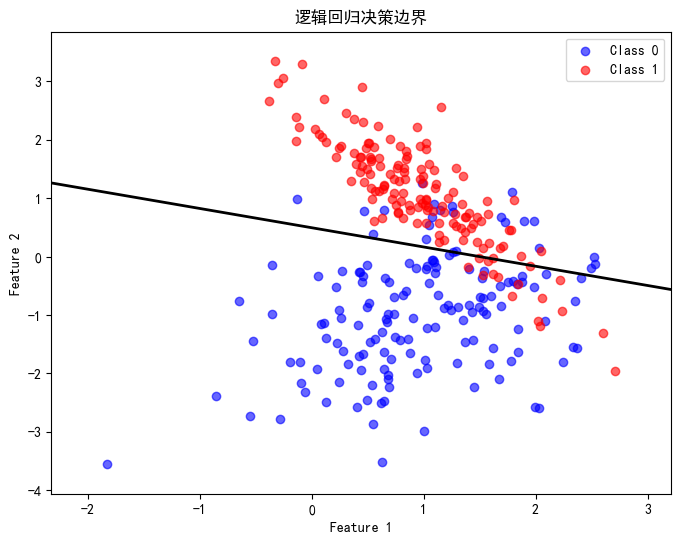

测试集准确率: 0.8800


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# 1. 生成两类线性可分数据
np.random.seed(42)
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0, 
                           n_informative=2, n_clusters_per_class=1, 
                           n_classes=2, random_state=42)
y = y.reshape(-1, 1)

# 划分训练集和测试集
X_train, y_train = X[:300], y[:300]
X_test, y_test = X[300:], y[300:]

# 2. 定义sigmoid和损失函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# 3. 梯度下降训练
def train_logistic_regression(X, y, lr=0.1, iterations=1000):
    n_samples, n_features = X.shape
    W = np.zeros((n_features, 1))
    b = 0
    
    losses = []
    
    for i in range(iterations):
        # 前向传播
        z = X @ W + b
        y_pred = sigmoid(z)
        
        # 计算损失
        loss = binary_cross_entropy(y_pred, y)
        losses.append(loss)
        
        # 反向传播
        dz = y_pred - y
        dW = (X.T @ dz) / n_samples
        db = np.mean(dz)
        
        # 更新参数
        W -= lr * dW
        b -= lr * db
        
        if (i + 1) % 200 == 0:
            print(f"Iteration {i+1}, Loss: {loss:.4f}")
    
    return W, b, losses

W, b, losses = train_logistic_regression(X_train, y_train, lr=0.1, iterations=1000)

# 4. 绘制决策边界
def plot_decision_boundary(X, y, W, b):
    plt.figure(figsize=(8, 6))
    
    # 绘制数据点
    plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1], c='blue', label='Class 0', alpha=0.6)
    plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1], c='red', label='Class 1', alpha=0.6)
    
    # 绘制决策边界
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ W + b)
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('逻辑回归决策边界')
    plt.legend()
    plt.show()

plot_decision_boundary(X_train, y_train, W, b)

# 计算测试准确率
y_test_pred = sigmoid(X_test @ W + b)
y_test_pred_labels = (y_test_pred >= 0.5).astype(int)
accuracy = np.mean(y_test_pred_labels == y_test)
print(f"测试集准确率: {accuracy:.4f}")